<a href="https://colab.research.google.com/github/fakarnanta/Bank-Customer-Prediction-Analysis/blob/main/Bank_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bank Marketing Campaign Analysis
Author: Daffa Damadhika Arkananta

Objective: Notebook ini bertujuan untuk menganalisis faktor-faktor yang mempengaruhi keberhasilan kampanye deposito bank dan membangun model prediksi untuk mengidentifikasi nasabah potensial.

### Data Loading & Understanding
Kita akan memuat dataset marketing bank dan melihat struktur datanya untuk memahami data dan kelengkapannya.

In [2]:
pip install kagglehub[pandas-datasets]

In [3]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "bank.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "janiobachmann/bank-marketing-dataset",
  file_path,
)

print("First 5 records:", df.head())
print("Dataset shape:", df.shape)
print("Dataset info:")
print(df.info())
print("\nMissing values per column:")
print(df.isnull().sum())

/tmp/ipython-input-1442131292.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 897k/897k [00:00<00:00, 5.52MB/s]


First 5 records:    age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  
Dataset shape: (11162, 17)
Dataset info:
<class 'pandas.core.frame.DataFrame'>
Ran

**Observasi Awal:**

Dari pengecekan data di atas, ada beberapa hal penting yang saya temukan:

1.  Ukuran Data:
Kita memiliki 11.162 data nasabah dengan 17 kolom.
2.  Kualitas Data:
Tidak ada data null disini.
3.  Jenis Fitur: Datanya campuran antara angka (seperti `age`, `balance`, `duration`) dan kategori teks (seperti `job`, `education`, `marital`).
4.  Tujuan : Fokus utama kita adalah kolom `deposit`. Isinya hanya "yes" atau "no", yang berarti tugas kita nanti adalah membuat model **Klasifikasi Biner** (menebak setuju/tolak).

Agar data bisa dianalisis secara statistik, kita perlu mengubah kolom target deposit (yang berisi "yes"/"no") menjadi angka biner:
* 1 = Yes
* 0 = No

In [4]:
target_col = 'deposit' if 'deposit' in df.columns else 'y'

df['target_num'] = df[target_col].apply(lambda x: 1 if x == 'yes' else 0)

print(f"Kolom target '{target_col}' berhasil diubah menjadi angka di kolom 'target_num'.")
df[[target_col, 'target_num']].head()

Kolom target 'deposit' berhasil diubah menjadi angka di kolom 'target_num'.


,deposit,target_num
0,yes,1
1,yes,1
2,yes,1
3,yes,1
4,yes,1


### Exploratory Data Analysis
Apakah jenis pekerjaan mempengaruhi keputusan seseorang untuk menabung deposito?. Kita akan melihat Conversion Rate per pekerjaan untuk melihat siapa target pasar terbaik kita.

/tmp/ipython-input-3185632762.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=job_conversion.values, y=job_conversion.index, palette='viridis')


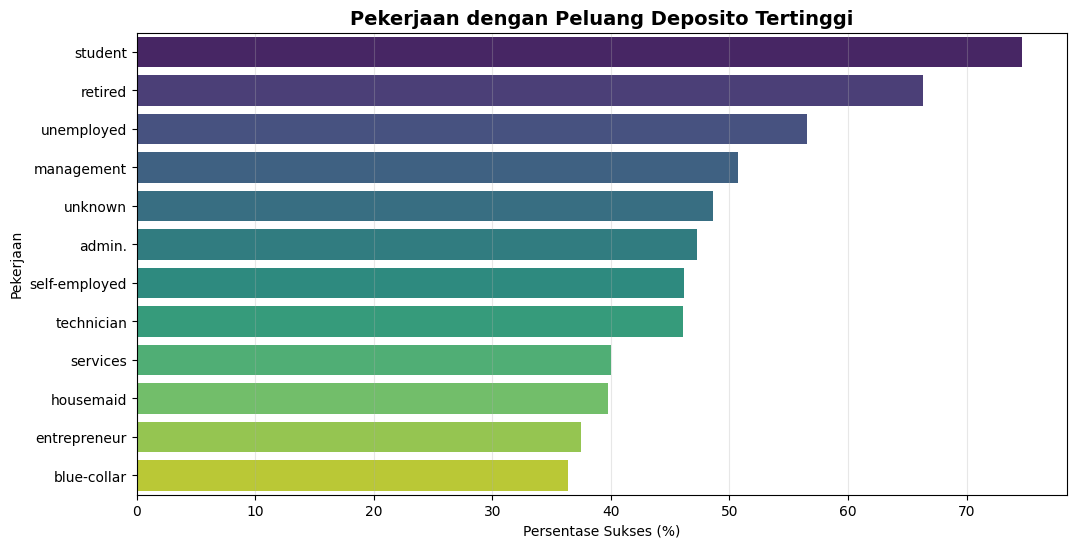

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
job_conversion = df.groupby('job')['target_num'].mean().sort_values(ascending=False) * 100
sns.barplot(x=job_conversion.values, y=job_conversion.index, palette='viridis')

plt.title('Pekerjaan dengan Peluang Deposito Tertinggi', fontsize=14, fontweight='bold')
plt.xlabel('Persentase Sukses (%)')
plt.ylabel('Pekerjaan')
plt.grid(axis='x', alpha=0.3)
plt.show()

**Insight:**
* Walaupun jumlah nasabah Management atau Blue-collar paling banyak, ternyata tingkat keberhasilan tertinggi justru ada pada kelompok Students (Pelajar) dan Retired (Pensiunan).


Business Question: Berapa lama durasi telepon yang ideal agar nasabah setuju?

/tmp/ipython-input-1455788001.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y='duration', data=df, palette='coolwarm')


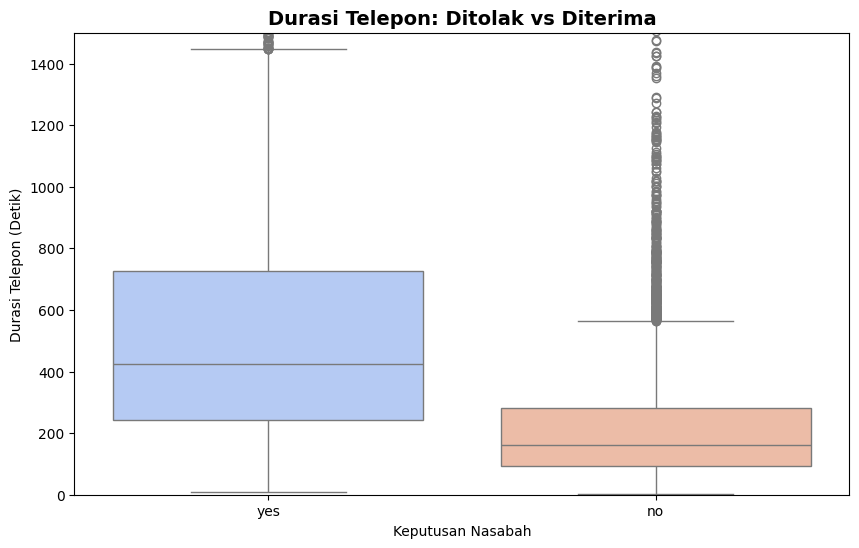

In [6]:
plt.figure(figsize=(10, 6))
target_col = 'deposit' if 'deposit' in df.columns else 'y'
sns.boxplot(x=target_col, y='duration', data=df, palette='coolwarm')

plt.title('Durasi Telepon: Ditolak vs Diterima', fontsize=14, fontweight='bold')
plt.xlabel('Keputusan Nasabah')
plt.ylabel('Durasi Telepon (Detik)')
plt.ylim(0, 1500) # Batasi biar grafik tidak kepanjangan
plt.show()

**Insight:**
* Terlihat perbedaan yang sangat signifikan antara durasi telepon nasabah Yes dan No.
* Nasabah yang setuju rata-rata berbicara lebih lama. Ini mengindikasikan bahwa ketertarikan nasabah berbanding lurus dengan durasi percakapan.
* Jika durasi panggilan masih di bawah 2-3 menit, peluang closing sangat kecil.

Business Question: Apakah nasabah dengan saldo tabungan yang tinggi lebih cenderung menerima tawaran deposito?

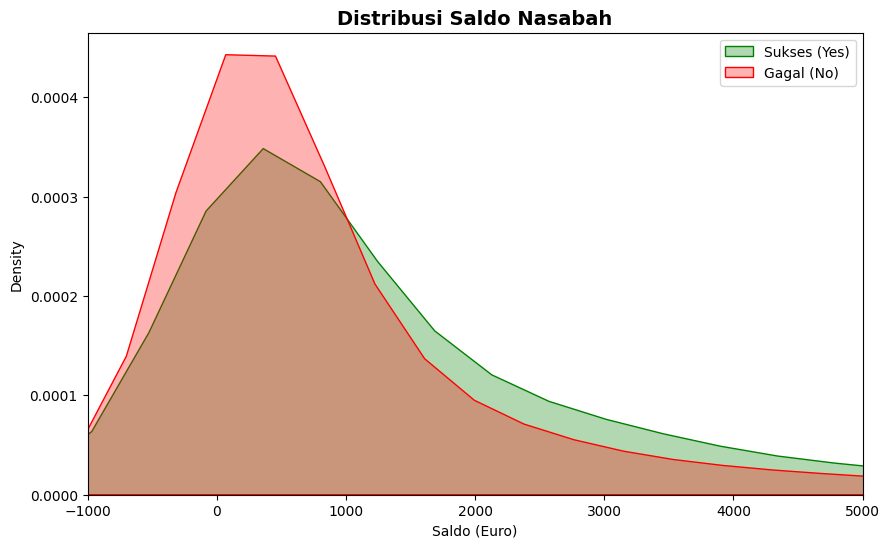

In [7]:

plt.figure(figsize=(10, 6))

target_col = 'deposit' if 'deposit' in df.columns else 'y'
sns.kdeplot(data=df[df[target_col]=='yes']['balance'], label='Sukses (Yes)', fill=True, color='green', alpha=0.3)
sns.kdeplot(data=df[df[target_col]=='no']['balance'], label='Gagal (No)', fill=True, color='red', alpha=0.3)

plt.title('Distribusi Saldo Nasabah', fontsize=14, fontweight='bold')
plt.xlim(-1000, 5000)
plt.xlabel('Saldo (Euro)')
plt.legend()
plt.show()

**Insight:**
* Median (nilai tengah) saldo nasabah yang deposit dan yang menolak tidak berbeda jauh.
* Ini menunjukkan bahwa saldo tabungan saat ini bukanlah satu-satunya indikator keberhasilan. Nasabah dengan saldo sedang pun bisa jadi target potensial jika pendekatannya tepat misalnya durasi telepon yang cukup.

Kita akan menggunakan Heatmap untuk melihat hubungan antar variabel numerik secara menyeluruh. Kita mencari kotak yang warnanya paling terang/gelap (korelasi kuat) terhadap `target_num`.

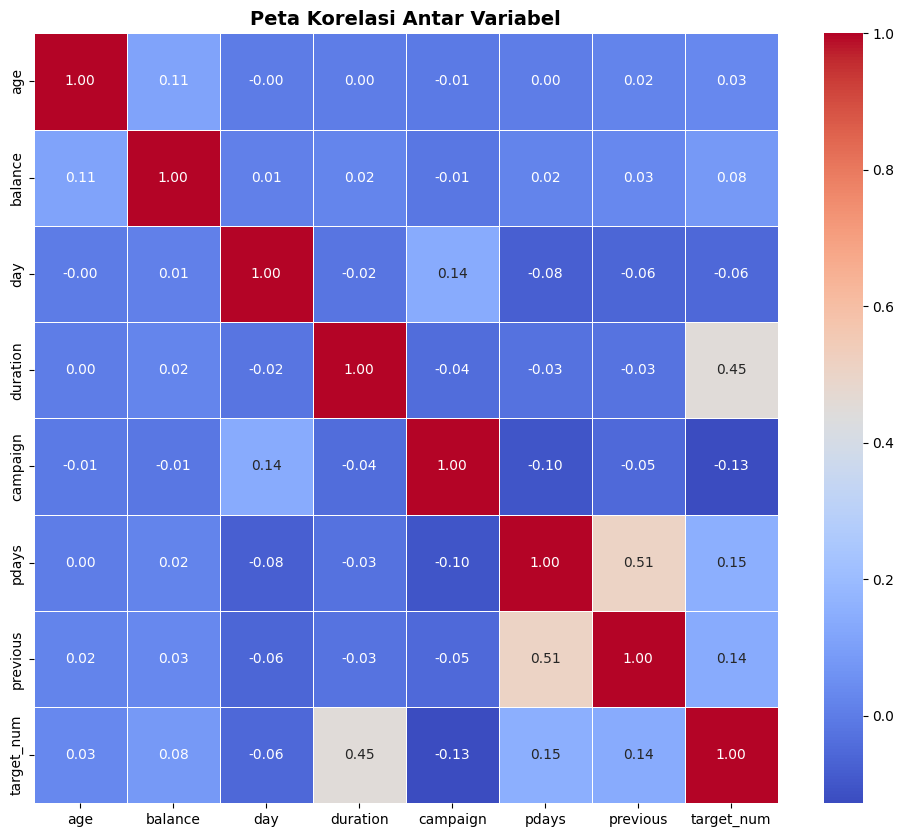

In [8]:

plt.figure(figsize=(12, 10))

cols_to_use = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'target_num']
df_corr = df[cols_to_use].corr()

sns.heatmap(df_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Peta Korelasi Antar Variabel', fontsize=14, fontweight='bold')
plt.show()


**Insight:**
* Variabel `duration` memiliki korelasi positif paling kuat terhadap `target_num`.
* Variabel lain seperti `campaign` justru memiliki korelasi negatif lemah (artinya: terlalu sering menelepon orang yang sama justru menurunkan peluang sukses).

Berdasarkan analisis di atas (Pekerjaan = Retired/Student, Balance > 0), kita bisa menyaring database untuk menemukan daftar nasabah prioritas. Dengan contoh calon nasabah dibawah ini:

In [9]:
ideal_customers = df[
    (df['job'].isin(['retired', 'student'])) &
    (df['balance'] > 0) &
    (df['campaign'] < 3)
]

print("Profil Nasabah Ideal")
print(f"Jumlah Kandidat: {len(ideal_customers)} orang")
print(f"Peluang Sukses di Grup ini: {round(ideal_customers['target_num'].mean() * 100, 2)}%")
print("\nContoh 5 Data Teratas:")
display(ideal_customers[['age', 'job', 'balance', 'education']].head())


Profil Nasabah Ideal
Jumlah Kandidat: 791 orang
Peluang Sukses di Grup ini: 73.83%

Contoh 5 Data Teratas:


,age,job,balance,education
7,60,retired,545,secondary
52,59,retired,1521,secondary
57,60,retired,1542,primary
119,34,retired,4499,primary
162,28,student,949,secondary


### Modeling
Sebelum melatih model AI, kita perlu mengubah semua data teks (kategorikal) menjadi angka. Kita akan menggunakan Label Encoding.

In [10]:
from sklearn.preprocessing import LabelEncoder

df_ml = df.copy()

cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

le = LabelEncoder()
for col in cat_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

df_ml.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,target_num
0,59,0,1,1,0,2343,1,0,2,5,8,1042,1,-1,0,3,yes,1
1,56,0,1,1,0,45,0,0,2,5,8,1467,1,-1,0,3,yes,1
2,41,9,1,1,0,1270,1,0,2,5,8,1389,1,-1,0,3,yes,1
3,55,7,1,1,0,2476,1,0,2,5,8,579,1,-1,0,3,yes,1
4,54,0,1,2,0,184,0,0,2,5,8,673,2,-1,0,3,yes,1


Kita akan membagi dataset dengan rasio 8:2

In [11]:
from sklearn.model_selection import train_test_split

X = df_ml.drop(['deposit', 'target_num'], axis=1)
y = df_ml['target_num']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(8929, 16)
(2233, 16)


Kita akan gunakan random forest dikarenakan data memiliki banyak tipe data yang berbeda dengan perbedaan nilai yang cukup ekstrim antar kolom

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.8334079713390058
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1166
           1       0.81      0.85      0.83      1067

    accuracy                           0.83      2233
   macro avg       0.83      0.83      0.83      2233
weighted avg       0.83      0.83      0.83      2233



Secara keseluruhan, model ini sangat layak diterapkan karena memiliki performa solid dengan akurasi 83% dan recall tinggi sebesar 85%, yang berarti ia mampu mengidentifikasi mayoritas nasabah potensial secara tepat.

/tmp/ipython-input-2321636463.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


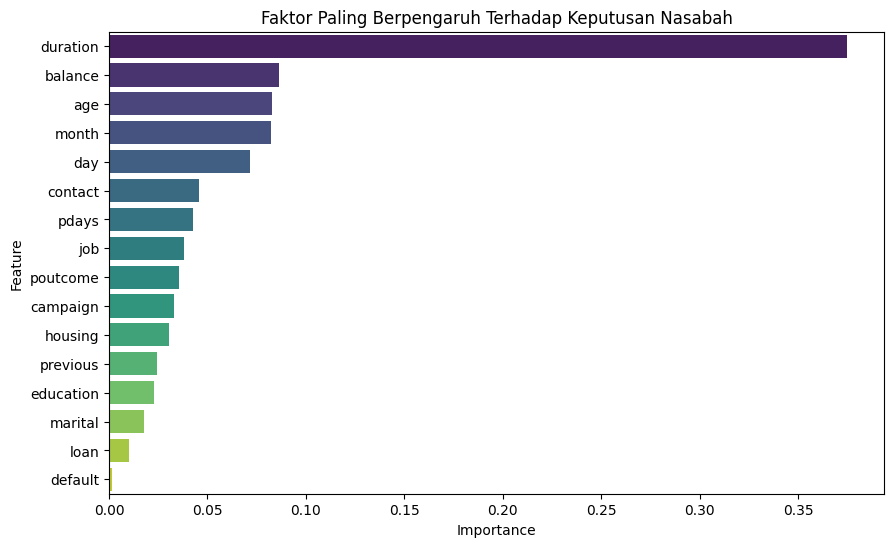

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importance = model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Faktor Paling Berpengaruh Terhadap Keputusan Nasabah')
plt.show()

Grafik tersebut menunjukkan bahwa durasi telepon adalah faktor penentu paling dominan dalam memprediksi deposit, jauh mengungguli profil sosial nasabah seperti pekerjaan atau pendidikan. Hal ini mengindikasikan bahwa kunci keberhasilan bisnis terletak pada kemampuan CS empertahankan interaksi yang lama dan berkualitas.

### Key Insight
Kunci sukses kampanye bank ini bukan terletak pada menargetkan profil pekerjaan tertentu, melainkan pada kemampuan sales membangun percakapan yang panjang (Durasi) dengan nasabah yang memiliki kondisi finansial memadai (Balance), dibantu oleh model yang sangat peka dalam mendeteksi peluang (High Recall).